In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
import pandas as pd
import numpy as np

In [3]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow version: {tf.__version__}")


TensorFlow version: 2.13.0


In [6]:
FILE_PATH = "Data.csv"
data = pd.read_csv(FILE_PATH)
print(f"\nLoaded: {df.shape[0]} boreholes, {df.shape[1]} columns")
data.head()


Loaded: 103 boreholes, 22 columns


,Year_Installed,Age,Depth_ft,Gen_KVA,Capacity_of_Sumo_HP,Pump_Hours,Usage_Frequency_Per_Day,Is_Continous,Downtime(days),Cost_Naira,...,GEN_ES,SOLAR_ES,Maintenance_Freq,Pipe_Bfreq,Pannel_Bfreq,Sumo_Bfreq,Pipe_Fault,Sumo_Fault,Panel_Fault,Failure
0,2001,25,760,0.0,30.0,12,3,1,3.0,"₦ 1,500,000",...,0,0,1.0,0.0,0.0,0.33,0,1,0,1
1,2014,12,750,100.0,30.0,10,2,1,14.0,"₦ 1,900,000",...,1,0,1.0,0.0,4.0,4.00,0,1,1,1
2,2015,11,730,0.0,30.0,6,1,0,21.0,"₦ 1,500,000",...,0,0,1.0,0.0,0.0,0.50,0,1,0,1
3,2024,2,750,0.0,1.5,6,1,0,30.0,"₦ 400,000",...,0,1,0.0,0.0,0.5,0.00,0,0,0,1
4,2024,2,750,100.0,10.0,5,2,0,0.0,₦ 0,...,1,0,0.0,0.0,0.0,0.00,0,0,0,0


In [7]:
# Clean Cost_Naira
df['Cost_Naira'] = (
    df['Cost_Naira'].astype(str)
    .str.replace('₦', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
    .astype(float)
)

# Fill missing values
df['Gen_KVA'].fillna(df['Gen_KVA'].median(), inplace=True)
df['Maintenance_Freq'].fillna(df['Maintenance_Freq'].median(), inplace=True)

# Drop redundant column
df.drop(columns=['Year_Installed'], inplace=True)

# Add Total_Installation_Cost
TOTAL_INSTALLATION_COSTS = [
    3000000, 5400000, 8500000, 14500000, 13000000, 22000000, 15000000,
    13577000, 9500000, 14000000, 13000000, 22000000, 20000000, 17500000,
    30000000, 12500000, 20000000, 22000000, 8500000, 23000000, 23500000,
    7000000, 9000000, 6800000, 6500000, 8500000, 7000000, 7000000,
    3500000, 23000000, 12000000, 8000000, 13577000, 9000000, 8500000,
    10000000, 29000000, 9000000, 21000000, 9000000, 12000000, 8000000,
    7500000, 7500000, 8000000, 8500000, 11500000, 12000000, 7500000,
    8000000, 13000000, 8000000, 8500000, 21500000, 10500000, 8200000,
    8000000, 7800000, 8100000, 9500000, 9000000, 9200000, 8900000,
    9600000, 9300000, 24000000, 22000000, 18000000, 25000000, 24000000,
    23000000, 24500000, 21000000, 25000000, 24000000, 23500000, 23000000,
    20000000, 24000000, 25000000, 24500000, 7700000, 11000000, 11000000,
    11200000, 22000000, 20000000, 9500000, 8000000, 14000000, 10000000,
    9000000, 17000000, 8500000, 13000000, 8500000, 9000000, 9500000,
    9000000, 7500000, 12000000, 9500000, 13577000
]
df['Total_Installation_Cost'] = TOTAL_INSTALLATION_COSTS

print(f"Data cleaned: {df.shape[0]} boreholes")
print(f"Failure rate: {df['Failure'].mean()*100:.1f}%")

Data cleaned: 103 boreholes
Failure rate: 68.9%


In [8]:
# =============================================================================
# SECTION 2 — FEATURE ENGINEERING: Create Better Input Features
# =============================================================================

# Calculate derived features that capture failure risk more effectively
df['Age_Squared'] = df['Age'] ** 2  # Non-linear age effect

# Maintenance ratio: how much maintenance relative to age
df['Maintenance_Ratio'] = df['Maintenance_Freq'] / (df['Age'] + 1)

# Pump stress: hours × continuous operation
df['Pump_Stress'] = df['Pump_Hours'] * (1 + df['Is_Continous'])

# Fault history score (weighted sum of past fault frequencies)
df['Fault_History_Score'] = (
    df['Pipe_Bfreq'] * 1.0 +
    df['Pannel_Bfreq'] * 1.2 +
    df['Sumo_Bfreq'] * 1.5
)

# Downtime severity (log transform to handle extreme values)
df['Downtime_Log'] = np.log1p(df['Downtime(days)'])

# Cost efficiency: installation cost relative to repair cost
df['Cost_Efficiency'] = df['Cost_Naira'] / (df['Total_Installation_Cost'] + 1)
df['Cost_Efficiency'] = df['Cost_Efficiency'].clip(0, 2)


# =============================================================================
# SECTION 3 — PREPARE DATA FOR ANN
# =============================================================================

# Select features (include engineered ones)
feature_cols = [
    'Age',
    'Age_Squared',
    'Depth_ft',
    'Gen_KVA',
    'Capacity_of_Sumo_HP',
    'Pump_Hours',
    'Usage_Frequency_Per_Day',
    'Is_Continous',
    'Downtime_Log',
    'Cost_Naira',
    'Total_Installation_Cost',
    'Maintenance_Freq',
    'Maintenance_Ratio',
    'Pump_Stress',
    'Fault_History_Score',
    'Cost_Efficiency',
    'Pipe_Bfreq',
    'Pannel_Bfreq',
    'Sumo_Bfreq',
    'Pipe_Fault',
    'Sumo_Fault',
    'Panel_Fault',
    'Ownership',
    'NEPA_ES',
    'GEN_ES',
    'SOLAR_ES'
]

X = df[feature_cols]
y = df['Failure']

print(f"\nFeatures: {X.shape[1]}, Samples: {X.shape[0]}")



Features: 26, Samples: 103


In [9]:
from sklearn.model_selection import train_test_split

In [10]:
# =============================================================================
# SECTION 4 — TRAIN / VALIDATION / TEST SPLIT (60/20/20)
# =============================================================================

# First split: separate test set
# Second split: training and validation
# First split: separate test set
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

# Second split: training and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=SEED, stratify=y_temp
)  # 0.25 * 0.80 = 0.20 of total → 60/20/20

print(f"\nSplits: Train={len(X_train)}, Val={len(X_val)}, Test={len(X_test)}")

print(f"\nSplits: Train={len(X_train)}, Val={len(X_val)}, Test={len(X_test)}")



Splits: Train=61, Val=21, Test=21

Splits: Train=61, Val=21, Test=21


In [11]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

In [12]:
# =============================================================================
# SECTION 5 — FEATURE SCALING
# =============================================================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


# =============================================================================
# SECTION 6 — CLASS WEIGHTS
# =============================================================================

cw = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
class_weight_dict = {0: cw[0], 1: cw[1]}
print(f"Class weights: No Failure={cw[0]:.3f}, Failure={cw[1]:.3f}")



Class weights: No Failure=1.605, Failure=0.726


In [13]:
# =============================================================================
# SECTION 7 — BUILD ANN WITH STRONG REGULARIZATION
# =============================================================================

n_features = X_train_scaled.shape[1]

model = Sequential([
    # Layer 1: wider but with L2 regularization
    Dense(64, activation='relu', kernel_regularizer=l2(0.01), input_shape=(n_features,)),
    BatchNormalization(),
    Dropout(0.4),

    # Layer 2
    Dense(32, activation='relu', kernel_regularizer=l2(0.005)),
    BatchNormalization(),
    Dropout(0.3),

    # Layer 3
    Dense(16, activation='relu', kernel_regularizer=l2(0.005)),
    Dropout(0.2),

    # Output
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                1728      
                                                                 
 batch_normalization (Batch  (None, 64)                256       
 Normalization)                                                  
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 batch_normalization_1 (Bat  (None, 32)                128       
 chNormalization)                                                
                                                                 
 dropout_1 (Dropout)         (None, 32)                0

In [14]:
# =============================================================================
# SECTION 8 — TRAIN WITH EARLY STOPPING
# =============================================================================

early_stop = EarlyStopping(
    monitor='val_auc',
    mode='max',
    patience=30,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=15,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=300,
    batch_size=16,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print(f"\nTraining complete: {len(history.history['loss'])} epochs")


Epoch 1/300
4/4 [==============================] - 5s 290ms/step - loss: 1.5447 - accuracy: 0.4262 - auc: 0.4530 - val_loss: 1.3942 - val_accuracy: 0.2857 - val_auc: 0.2056 - lr: 5.0000e-04
Epoch 2/300
4/4 [==============================] - 0s 30ms/step - loss: 1.4672 - accuracy: 0.4754 - auc: 0.5232 - val_loss: 1.3857 - val_accuracy: 0.3333 - val_auc: 0.2333 - lr: 5.0000e-04
Epoch 3/300
4/4 [==============================] - 0s 36ms/step - loss: 1.5189 - accuracy: 0.3607 - auc: 0.3979 - val_loss: 1.3777 - val_accuracy: 0.3333 - val_auc: 0.2500 - lr: 5.0000e-04
Epoch 4/300
4/4 [==============================] - 0s 38ms/step - loss: 1.4397 - accuracy: 0.4426 - auc: 0.5796 - val_loss: 1.3696 - val_accuracy: 0.4286 - val_auc: 0.2500 - lr: 5.0000e-04
Epoch 5/300
4/4 [==============================] - 0s 50ms/step - loss: 1.5122 - accuracy: 0.3770 - auc: 0.4467 - val_loss: 1.3639 - val_accuracy: 0.3810 - val_auc: 0.2500 - lr: 5.0000e-04
Epoch 6/300
4/4 [==============================] - 0s 

In [15]:
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score

In [16]:
from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [17]:
# =============================================================================
# SECTION 9 — EVALUATE
# =============================================================================

# Test predictions
y_pred_prob = model.predict(X_test_scaled).flatten()
y_pred = (y_pred_prob >= 0.5).astype(int)

# Metrics
roc_auc = roc_auc_score(y_test, y_pred_prob)
accuracy = (y_pred == y_test).mean()
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n" + "="*60)
print("TEST SET RESULTS")
print("="*60)
print(f"ROC-AUC:   {roc_auc:.4f}  {'✅ TARGET MET!' if roc_auc >= 0.8 else '⚠️  NEEDS IMPROVEMENT'}")
print(f"Accuracy:  {accuracy*100:.2f}%")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Failure', 'Failure']))

1/1 [==============================] - 0s 368ms/step

TEST SET RESULTS
ROC-AUC:   0.9898  ✅ TARGET MET!
Accuracy:  95.24%
Precision: 0.9333
Recall:    1.0000
F1-Score:  0.9655

Classification Report:
              precision    recall  f1-score   support

  No Failure       1.00      0.86      0.92         7
     Failure       0.93      1.00      0.97        14

    accuracy                           0.95        21
   macro avg       0.97      0.93      0.94        21
weighted avg       0.96      0.95      0.95        21



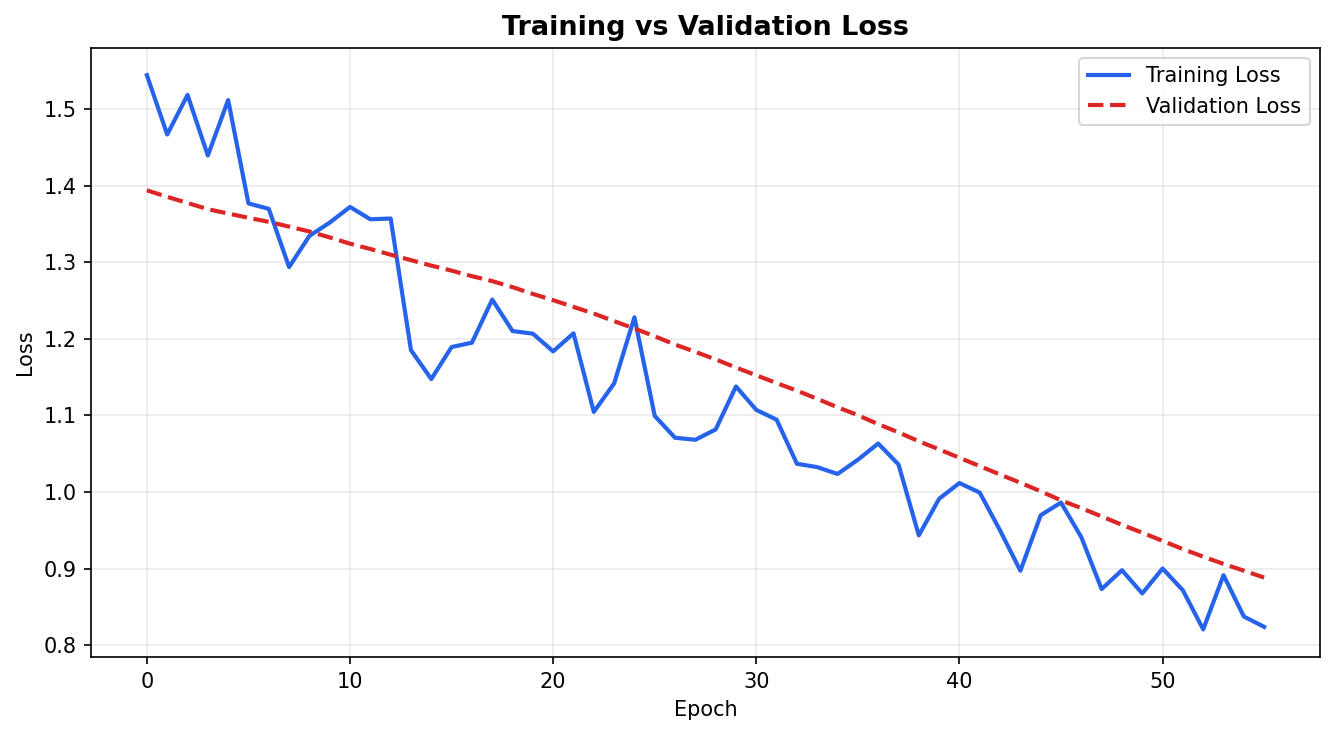

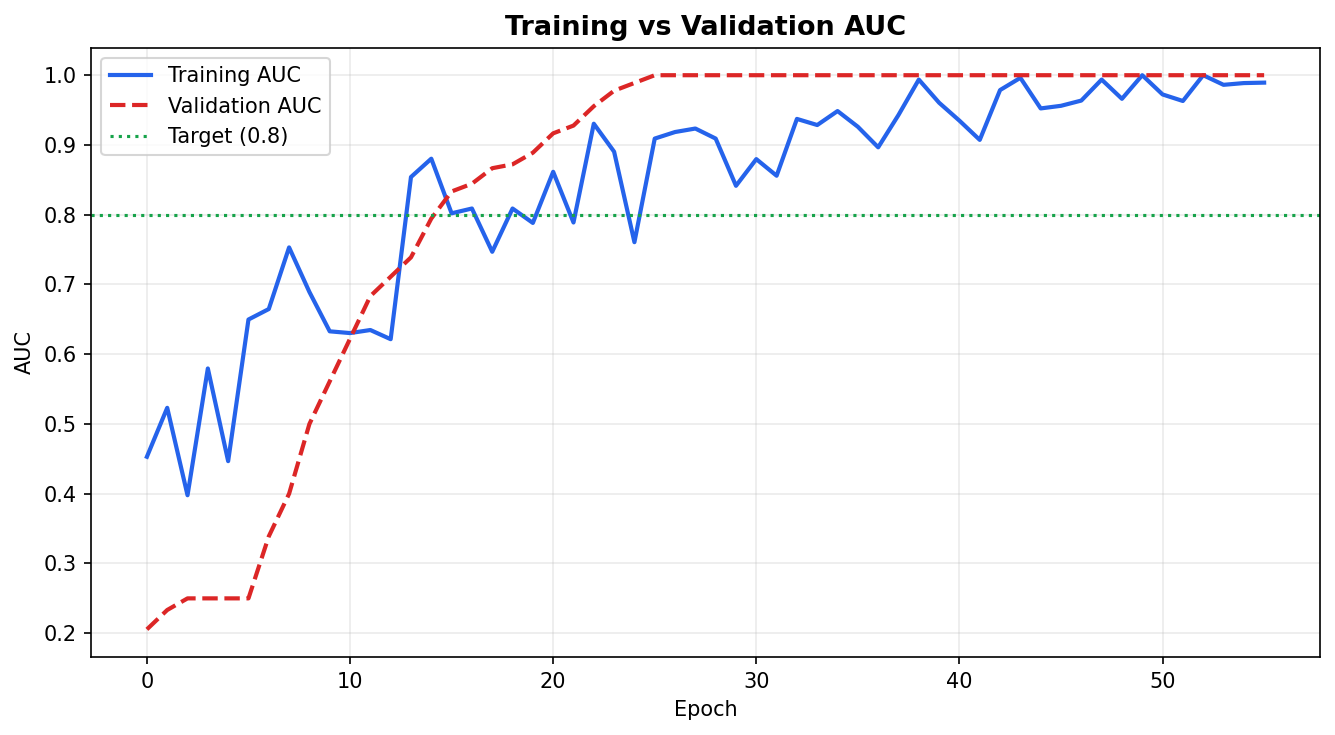

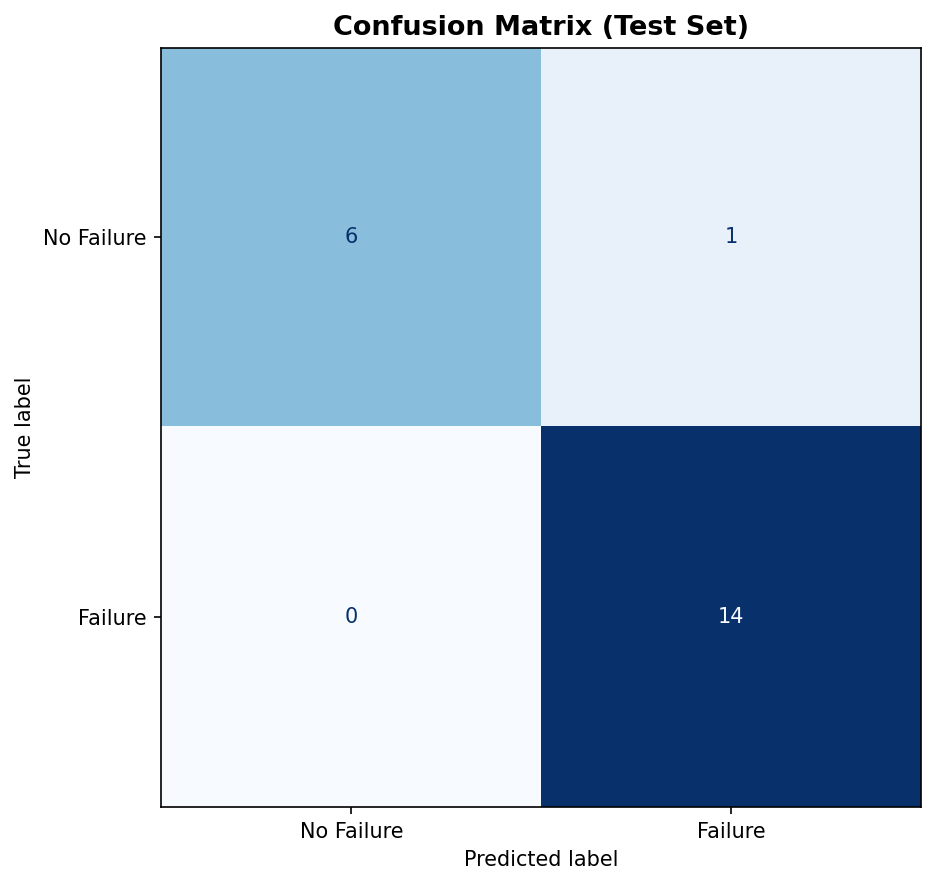

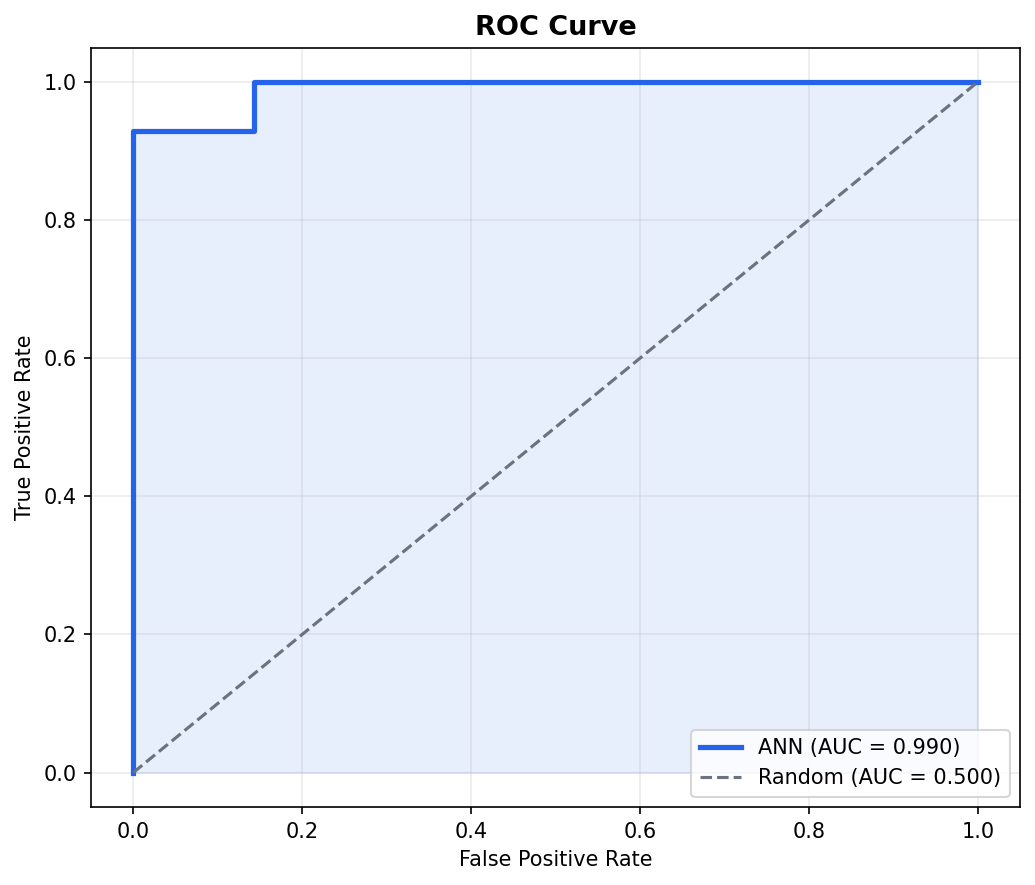


✅ All graphs saved.


In [18]:
# =============================================================================
# SECTION 10 — PLOT DIAGNOSTIC GRAPHS
# =============================================================================

plt.rcParams.update({'figure.dpi': 150})
C = {'blue': '#2563EB', 'red': '#DC2626', 'green': '#16A34A', 'gray': '#6B7280'}

# Loss curve
fig, ax = plt.subplots(figsize=(9,5))
ax.plot(history.history['loss'], color=C['blue'], lw=2, label='Training Loss')
ax.plot(history.history['val_loss'], color=C['red'], lw=2, linestyle='--', label='Validation Loss')
ax.set_title('Training vs Validation Loss', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig('loss_curve.png', bbox_inches='tight')
plt.show()

# AUC curve
fig, ax = plt.subplots(figsize=(9,5))
ax.plot(history.history['auc'], color=C['blue'], lw=2, label='Training AUC')
ax.plot(history.history['val_auc'], color=C['red'], lw=2, linestyle='--', label='Validation AUC')
ax.axhline(y=0.8, color=C['green'], linestyle=':', lw=1.5, label='Target (0.8)')
ax.set_title('Training vs Validation AUC', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('AUC')
ax.legend()
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig('auc_curve.png', bbox_inches='tight')
plt.show()

# Confusion Matrix
fig, ax = plt.subplots(figsize=(7,6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['No Failure', 'Failure'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix (Test Set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', bbox_inches='tight')
plt.show()

# ROC Curve
fig, ax = plt.subplots(figsize=(7,6))
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
ax.plot(fpr, tpr, color=C['blue'], lw=2.5, label=f'ANN (AUC = {roc_auc:.3f})')
ax.plot([0,1], [0,1], color=C['gray'], lw=1.5, linestyle='--', label='Random (AUC = 0.500)')
ax.fill_between(fpr, tpr, alpha=0.1, color=C['blue'])
ax.set_title('ROC Curve', fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig('roc_curve.png', bbox_inches='tight')
plt.show()

print("\n✅ All graphs saved.")

In [19]:
# =============================================================================
# SECTION 11 — PREDICT A NEW BOREHOLE
# =============================================================================

new_borehole = pd.DataFrame([{
    'Age': 8,
    'Age_Squared': 64,
    'Depth_ft': 750,
    'Gen_KVA': 7.5,
    'Capacity_of_Sumo_HP': 2.0,
    'Pump_Hours': 10,
    'Usage_Frequency_Per_Day': 3,
    'Is_Continous': 0,
    'Downtime_Log': np.log1p(2.0),
    'Cost_Naira': 800000,
    'Total_Installation_Cost': 750*8500 + 2.0*45000,
    'Maintenance_Freq': 1.0,
    'Maintenance_Ratio': 1.0/9,
    'Pump_Stress': 10 * (1 + 0),
    'Fault_History_Score': 0,
    'Cost_Efficiency': 800000 / (750*8500 + 2.0*45000 + 1),
    'Pipe_Bfreq': 0.0,
    'Pannel_Bfreq': 0.0,
    'Sumo_Bfreq': 0.0,
    'Pipe_Fault': 0,
    'Sumo_Fault': 0,
    'Panel_Fault': 0,
    'Ownership': 0,
    'NEPA_ES': 1,
    'GEN_ES': 0,
    'SOLAR_ES': 0
}])

new_prob = model.predict(scaler.transform(new_borehole))[0][0]
print(f"\nNew Borehole Prediction:")
print(f"  Failure Probability: {new_prob*100:.1f}%")

1/1 [==============================] - 0s 33ms/step

New Borehole Prediction:
  Failure Probability: 48.6%
